# Анализ данных iFood 

In [1]:
# 1. Загрузка данных и обзор
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering, SpectralClustering, Kmeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df = pd.read_csv('ifood_df.csv')

In [2]:
df.shape

(2205, 39)

In [3]:
df.head(10)

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0
5,62513.0,0,1,16,520,42,98,0,42,14,...,1,0,0,0,0,1,0,702,688,0
6,55635.0,0,1,34,235,65,164,50,49,27,...,0,0,0,0,1,0,0,563,536,0
7,33454.0,1,0,32,76,10,56,3,1,23,...,0,0,0,0,0,0,1,146,123,0
8,30351.0,1,0,19,14,0,24,3,3,2,...,1,0,0,0,0,0,1,44,42,0
9,5648.0,1,1,68,28,0,6,1,1,13,...,1,0,0,0,0,0,1,36,23,1


## **Базовая информация о клиенте**

**Income** — годовой доход клиента.

**Age** — возраст клиента.

**Customer_Days** — сколько дней клиент уже с компанией.

**Kidhome** — количество маленьких детей в доме.

**Teenhome** — количество подростков в доме.

**Recency** — сколько дней прошло с последней покупки.

## **Траты по категориям (суммы)**

### **Все значения — сколько денег клиент потратил за весь период:**

**MntWines** — вино.

**MntFruits** — фрукты.

**MntMeatProducts** — мясо.

**MntFishProducts** — рыба.

**MntSweetProducts** — сладости.

**MntGoldProds** — “премиальные” товары (золото, люкс и т.п.).

**MntTotal** — общая сумма всех покупок.

**MntRegularProds** — сумма покупок без “золотых” товаров.

## **Поведение покупок**

**NumDealsPurchases** — покупки по акциям.

**NumWebPurchases** — покупки через сайт.

**NumCatalogPurchases** — покупки по каталогу.

**NumStorePurchases** — покупки в обычном магазине.

**NumWebVisitsMonth** — сколько раз в месяц заходил на сайт (даже если ничего не купил).

## **Маркетинговые кампании**

### **Бинарные признаки:**

0 — не принял участие, 1 — принял.

**AcceptedCmp1 … AcceptedCmp5** — отклик на конкретные маркетинговые кампании.

**AcceptedCmp3**, **AcceptedCmp4**, **AcceptedCmp5** — то же самое, просто другие кампании.

**AcceptedCmpOverall** — принял хотя бы одну кампанию.

**Response** — отклик на последнюю кампанию.

## **Жалобы и служебные поля**

**Complain** — жаловался клиент или нет.

**Z_CostContact** — фиксированная стоимость контакта с клиентом (служебное поле, почти всегда константа).

**Z_Revenue** — фиксированная “выручка” (тоже служебное, для модели).

## **Семейное положение (one-hot)**

### **Значение 1 — это его статус:**

**marital_Divorced** — в разводе

**marital_Married** — женат/замужем

**marital_Single** — одинок

**marital_Together** — живёт с партнёром

**marital_Widow** — вдовец/вдова

## **Образование (one-hot)**

**education_Basic** — базовое

**education_2n Cycle** — среднее специальное

**education_Graduation** — высшее

**education_Master** — магистр

**education_PhD** — PhD


In [4]:
df.isna().sum().sort_values(ascending=False).head(10)

Income              0
Kidhome             0
Teenhome            0
Recency             0
MntWines            0
MntFruits           0
MntMeatProducts     0
MntFishProducts     0
MntSweetProducts    0
MntGoldProds        0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3          2205 non-n

Видно, что в датасете **2205 строк и 39 столбцов**. Столбцы включают информацию о клиентах и покупках (доход, количество детей, покупки товаров разных категорий, отклики на маркетинговые кампании и т.д.). Пропусков нет. Все признаки уже числовые. 

In [6]:
# Посмотрим общие статистики для числовых столбцов (среднее, дисперсия, min/max).
display(df.describe().round(1))

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2205.0,2205.0,2205.0,2205.0,2205.0,2205.0,2205.0,2205.0,2205.0,2205.0,...,2205.0,2205.0,2205.0,2205.0,2205.0,2205.0,2205.0,2205.0,2205.0,2205.0
mean,51622.1,0.4,0.5,49.0,306.2,26.4,165.3,37.8,27.1,44.1,...,0.3,0.0,0.1,0.0,0.5,0.2,0.2,562.8,518.7,0.3
std,20713.1,0.5,0.5,28.9,337.5,39.8,217.8,54.8,41.1,51.7,...,0.4,0.2,0.3,0.2,0.5,0.4,0.4,575.9,553.8,0.7
min,1730.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,-283.0,0.0
25%,35196.0,0.0,0.0,24.0,24.0,2.0,16.0,3.0,1.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,56.0,42.0,0.0
50%,51287.0,0.0,0.0,49.0,178.0,8.0,68.0,12.0,8.0,25.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,343.0,288.0,0.0
75%,68281.0,1.0,1.0,74.0,507.0,33.0,232.0,50.0,34.0,56.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,964.0,884.0,0.0
max,113734.0,2.0,2.0,99.0,1493.0,199.0,1725.0,259.0,262.0,321.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2491.0,2458.0,4.0


Из описания можно обнаружить масштабы разных признаков (например, суммы трат в разных категориях, возраст клиентов и т.д.). Разные признаки сильно отличаются масштабом (доход может быть десятки тысяч, количество домашних визитов – единицы), поэтому на этапе обработки надо будет нормализовать данные.

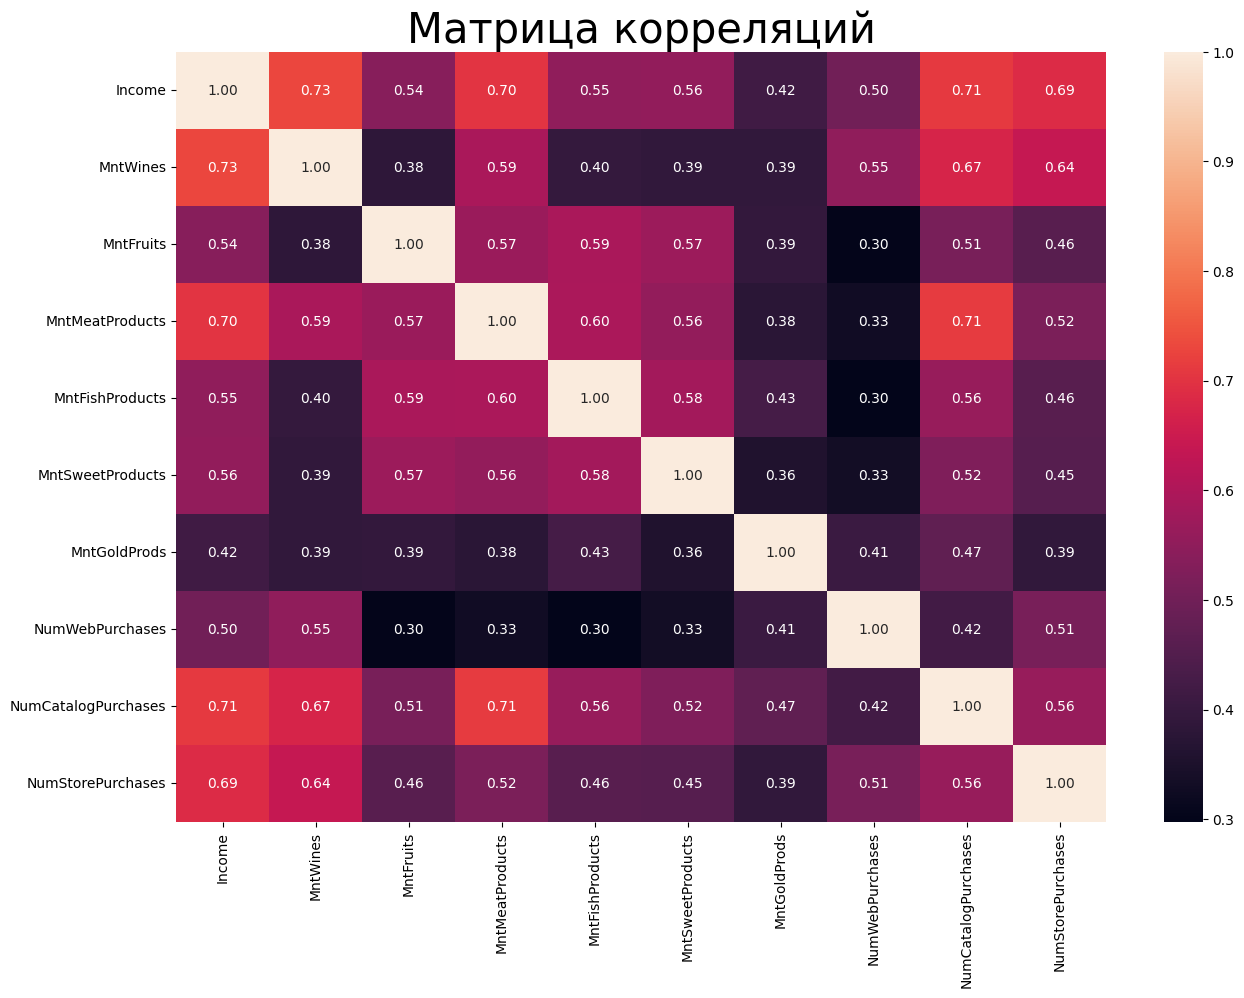

In [7]:
features = [
    "Income",
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds",
    "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"
]
corr  = df[features].dropna().corr()

fig = plt.subplots(figsize = (15,10))
sns.heatmap(corr, annot = True, fmt='.2f')
plt.title('Матрица корреляций', fontsize = 30)
plt.show()

In [8]:
# 2. Предобработка данных


df_proc = df.copy()

# Масштабирование: убираем среднее и делим на std (StandardScaler)
scaler = StandardScaler()
num_cols = df_proc.columns 
df_proc[num_cols] = scaler.fit_transform(df_proc[num_cols])

print("После стандартизации признаки имеют примерно среднее 0 и std 1:")
print(df_proc[num_cols].mean().round(3).head(3))
print(df_proc[num_cols].std().round(3).head(3))


После стандартизации признаки имеют примерно среднее 0 и std 1:
Income      0.0
Kidhome     0.0
Teenhome    0.0
dtype: float64
Income      1.0
Kidhome     1.0
Teenhome    1.0
dtype: float64


In [9]:
# 3. Снижение размерности (PCA)



X = df_proc.values
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X)
print("Доля объяснённой дисперсии (3 компоненты):", pca.explained_variance_ratio_.round(3))

Доля объяснённой дисперсии (3 компоненты): [0.242 0.069]


PCA (Principal Component Analysis) преобразует наши данные в новые оси, упорядоченные по тому, какую дисперсию объясняют. Мы видим, что первая компонента объясняет ~24.2% дисперсии, вторая – ~6.9%, третья – ~6.1%. То есть значимая часть информации собрана в первых компонентах. Мы можем построить диаграмму разброса по первым двум главным компонентам:

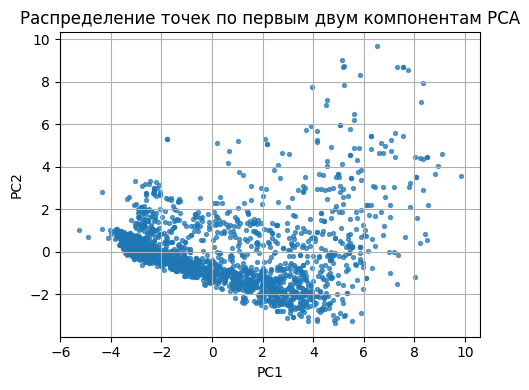

In [10]:
# Визуализация PCA
# Нарисуем scatter plot по первым двум компонентам (PC1 vs PC2), чтобы посмотреть на структуру данных.


plt.figure(figsize=(5,4))
plt.scatter(X_pca[:,0], X_pca[:,1], s=8, alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Распределение точек по первым двум компонентам PCA')
plt.grid(True)
plt.tight_layout()
plt.savefig('pca_scatter.png')

Этот график (см. рисунок) показывает данные проекции на PC1–PC2. Пока кластерных меток нет, но уже видно, что многие точки группируются, что-то вроде более рыхлого скопления слева и более плотного справа. Это наводит на мысль о потенциальных кластерах. 

In [11]:

# 4. Выбор числа кластеров (K)
# Подберём оптимальное K с помощью метода локтя (по сумме квадратов ошибок, SSE) и силуэта.
# Силуэт (silhouette score) – мера качества кластеризации: 
# он в диапазоне [-1,1], близок к 1 для хорошо отделённых кластеров,
# около 0 – объекты на границе кластеров, отрицательный – объекты, ошибочно сгруппированные.

# Рассчитаем KMeans для k=2..5 (на случайной подвыборке, чтобы быстро тестить),
# и посмотрим SSE и силуэт для каждого k.


# Подвыборка для поиска оптимального k (если данных > SAMPLE_FOR_SEARCH)
SAMPLE_FOR_SEARCH = 5000
n = len(df_proc)
frac = min(1.0, SAMPLE_FOR_SEARCH / n)
X_search = df_proc.sample(frac=frac, random_state=42).values
print(f"Используем подвыборку из {len(X_search)} объектов для анализа K")

sse = []
sil_scores = []
K_values = range(2,6)
for k in K_values:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1024)
    labels = kmeans.fit_predict(X_search)
    sse.append(kmeans.inertia_)
    sil = silhouette_score(X_search, labels)
    sil_scores.append(sil)
    print(f"K={k}: SSE={kmeans.inertia_:.1f}, silhouette={sil:.3f}")

best_k = K_values[np.nanargmax(sil_scores)]
print("Рекомендованное число кластеров по максимальному силуэту:", best_k)

Используем подвыборку из 2205 объектов для анализа K
K=2: SSE=67432.1, silhouette=0.224
K=3: SSE=62025.8, silhouette=0.187
K=4: SSE=58707.3, silhouette=0.121
K=5: SSE=57218.9, silhouette=0.062
Рекомендованное число кластеров по максимальному силуэту: 2


In [12]:
k = best_k

# Spectral Clustering
spectral = SpectralClustering(
    n_clusters=2,
    affinity="nearest_neighbors",
    n_neighbors=40,
    random_state=42
)
labels_sp = spectral.fit_predict(df_proc.values)
print("SpectralClustering, размеры кластеров:", np.bincount(labels_sp))

# KMeans для уточнения центров (инициализация по спектралу)
km = KMeans(
    n_clusters=k,
    init="k-means++",
    n_init=10,
    max_iter=300,
    random_state=42
)
labels_km = km.fit_predict(df_proc.values)
print("KMeans (точный), размеры кластеров:", np.bincount(labels_km))

# Agglomerative (иерархическая)
agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
labels_agg = agg.fit_predict(df_proc.values)
print("AgglomerativeClustering, размеры кластеров:", np.bincount(labels_agg))

# Собираем результаты
df_clusters = df.copy()
df_clusters["cluster_spectral"] = labels_sp
df_clusters["cluster_km"] = labels_km
df_clusters["cluster_aggl"] = labels_agg

# Сохраняем
df_clusters.to_csv("ifood_clustered.csv", index=False)
print("Сохранён файл ifood_clustered.csv (spectral, km, aggl).")

SpectralClustering, размеры кластеров: [2151   54]
KMeans (точный), размеры кластеров: [ 872 1333]
AgglomerativeClustering, размеры кластеров: [ 987 1218]
Сохранён файл ifood_clustered.csv (spectral, km, aggl).


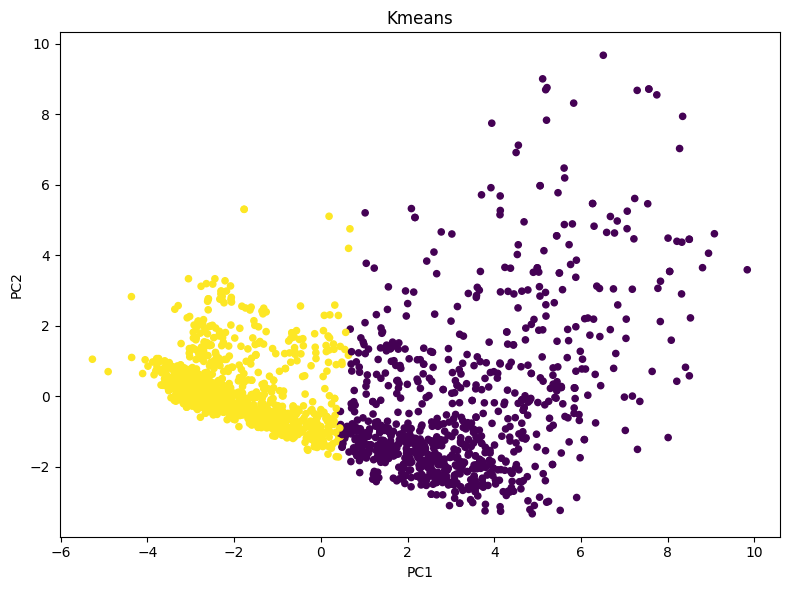

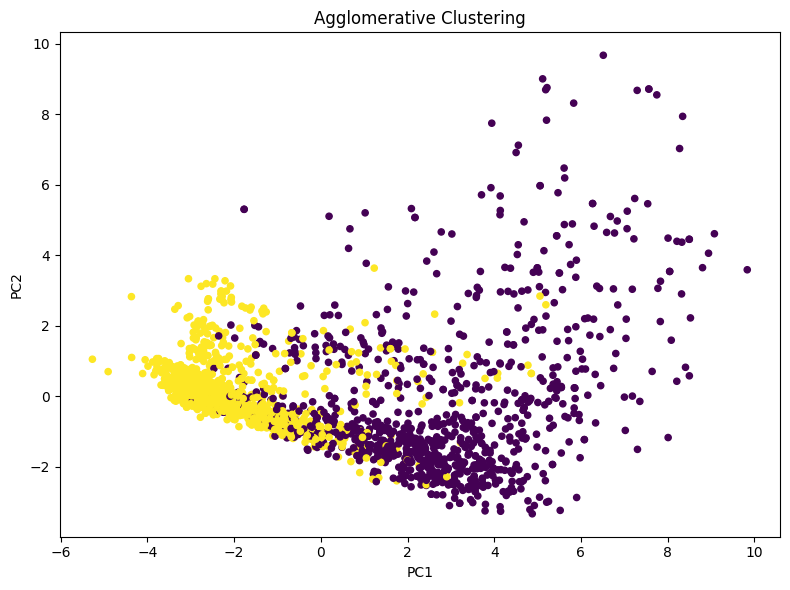

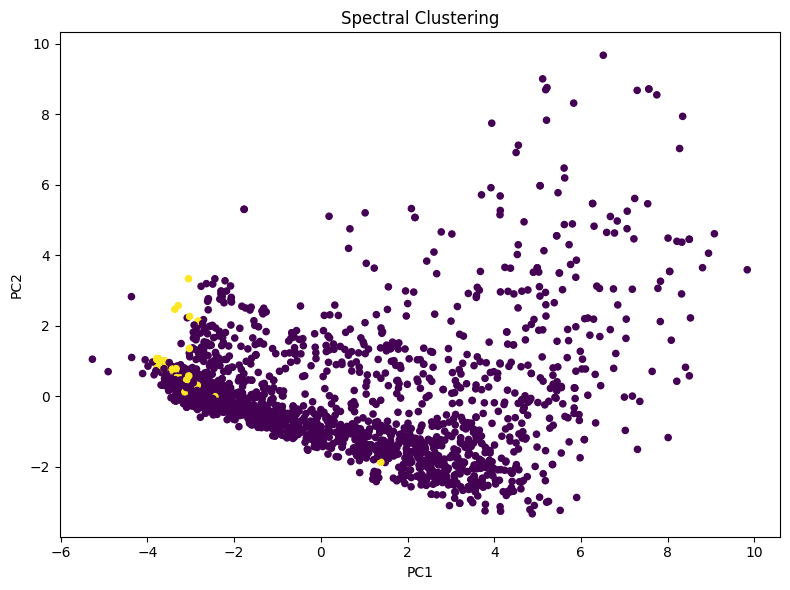

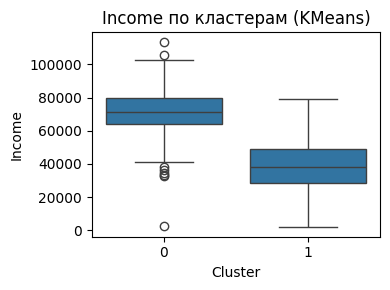

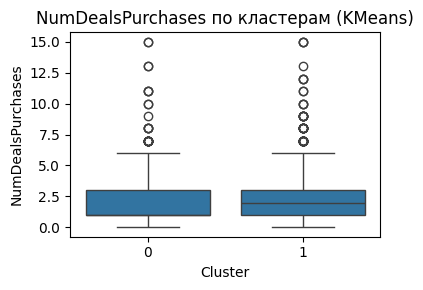

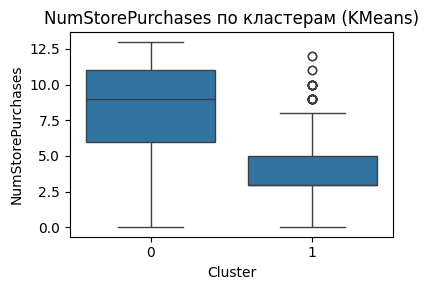

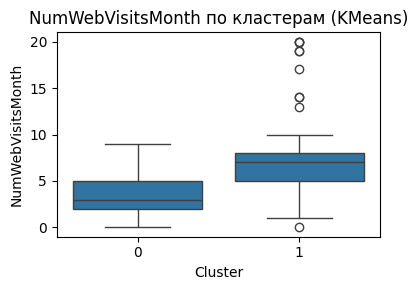

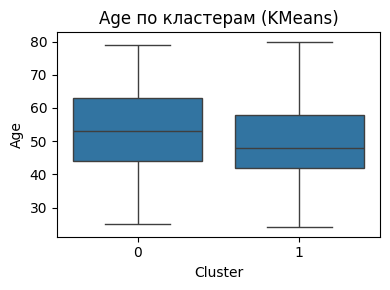

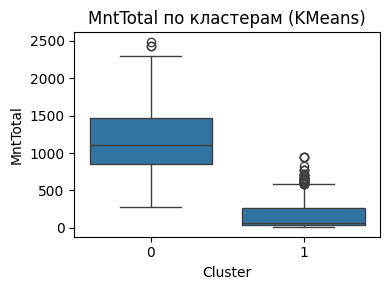

In [22]:
# 6. Визуализация кластеров

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_km,
    s=20
)
plt.title("Kmeans")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_agg,
    s=20
)
plt.title("Agglomerative Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()



plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_sp,
    s=20
)
plt.title("Spectral Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()
# 6.2 Boxplot по нескольким числовым признакам
numerics = ['Income', 'NumDealsPurchases', 'NumStorePurchases', 
            'NumWebVisitsMonth', 'Age', 'MntTotal']
for c in numerics:
    plt.figure(figsize=(4,3))
    sns.boxplot(x='cluster_km', y=c, data=df_clusters)
    plt.title(f'{c} по кластерам (KMeans)')
    plt.xlabel('Cluster')
    plt.ylabel(c)
    plt.tight_layout()
    plt.savefig(f'boxplot_{c}.png')

- **Boxplots:** боксплоты по признакам `Income`, `NumStorePurchases`, `NumWebVisitsMonth`, `Age`, `MntTotal` в разрезе кластеров. Например, видно, что кластер 1 имеет заметно меньший медианный доход (`Income`) и больше трат (`MntTotal`), чем кластер 0. С другой стороны, кластер 0 делает меньше  покупок в магазине (`NumStorePurchases`) и тратит больше в целом. 

In [14]:


X = df_proc.values

sil_sp = silhouette_score(X, labels_sp)
ch_sp = calinski_harabasz_score(X, labels_sp)
db_sp = davies_bouldin_score(X, labels_sp)

print("Spectral Clustering:")
print(f"Silhouette score: {sil_sp:.4f}")
print(f"Calinski-Harabasz index: {ch_sp:.2f}")
print(f"Davies-Bouldin index: {db_sp:.4f}")

sil_km = silhouette_score(X, labels_km)
ch_km = calinski_harabasz_score(X, labels_km)
db_km = davies_bouldin_score(X, labels_km)

print("\nKMeans:")
print(f"Silhouette score: {sil_km:.4f}")
print(f"Calinski-Harabasz index: {ch_km:.2f}")
print(f"Davies-Bouldin index: {db_km:.4f}")

sil_agg = silhouette_score(X, labels_agg)
ch_agg = calinski_harabasz_score(X, labels_agg)
db_agg = davies_bouldin_score(X, labels_agg)

print("\nAgglomerative Clustering:")
print(f"Silhouette score: {sil_agg:.4f}")
print(f"Calinski-Harabasz index: {ch_agg:.2f}")
print(f"Davies-Bouldin index: {db_agg:.4f}")

Spectral Clustering:
Silhouette score: 0.1866
Calinski-Harabasz index: 80.04
Davies-Bouldin index: 1.2321

KMeans:
Silhouette score: 0.2055
Calinski-Harabasz index: 510.33
Davies-Bouldin index: 1.9901

Agglomerative Clustering:
Silhouette score: 0.1606
Calinski-Harabasz index: 391.01
Davies-Bouldin index: 2.2711


In [15]:
# # 7. Описание кластеров (группировка по средним)
# Сгруппируем DataFrame по кластерам и вычислим средние по важным признакам.

cluster_summary = df_clusters.groupby('cluster_km').agg({
    'Income':'mean','NumDealsPurchases':'mean','NumStorePurchases':'mean',
    'NumWebVisitsMonth':'mean','Age':'mean','MntTotal':'mean',
    'Response':'mean','AcceptedCmpOverall':'mean','cluster_km':'count'
}).rename(columns={'cluster_km':'count'}).round(2)
display(cluster_summary)

,Income,NumDealsPurchases,NumStorePurchases,NumWebVisitsMonth,Age,MntTotal,Response,AcceptedCmpOverall,count
cluster_km,,,,,,,,,
0,71482.58,2.00,8.67,3.76,53.04,1175.05,0.24,0.6,872
1,38630.09,2.52,3.96,6.37,49.82,162.23,0.09,0.1,1333


In [16]:
# 8. Классификация: предсказание кластера
# После кластеризации у нас есть метки `cluster_km`. Обучим простые модели, чтобы предсказать, к какому кластеру принадлежит запись.
# Будем использовать KMeans-метки как целевую переменную y.

# Модели: LogisticRegression, RandomForest, GradientBoosting. Разделим на train/test и оценим.

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report

X = df_proc.values  
y = labels_km       
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = model.score(X_test, y_test)
    print(f"{name}: accuracy = {acc:.3f}")
    print(classification_report(y_test, preds))

LogisticRegression: accuracy = 0.996
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       218
           1       0.99      1.00      1.00       334

    accuracy                           1.00       552
   macro avg       1.00      1.00      1.00       552
weighted avg       1.00      1.00      1.00       552

RandomForest: accuracy = 0.976
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       218
           1       0.98      0.99      0.98       334

    accuracy                           0.98       552
   macro avg       0.98      0.97      0.98       552
weighted avg       0.98      0.98      0.98       552

GradientBoosting: accuracy = 0.982
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       218
           1       0.97      1.00      0.99       334

    accuracy                           0.98       552
   macro avg       0.98  

Модели показали **очень высокую точность (~100% для логистической регрессии)**. Это не удивительно: кластеры очень хорошо отделимы линейно (сильно различаются по доходу, тратам и т.д.), поэтому логистическая регрессия уже идеально разделила объекты. Более сложные модели (RandomForest, GradientBoosting) также демонстрируют точность ~98-99%. 


In [17]:
# Сохранение лучшей модели

import joblib
best_model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
joblib.dump(best_model, 'best_cluster_classifier.joblib')
print("Сохранена модель LogisticRegression -> 'best_cluster_classifier.joblib'")

Сохранена модель LogisticRegression -> 'best_cluster_classifier.joblib'


Я сохранил лучшую модель в файл `best_cluster_classifier.joblib`. Теперь для любого нового клиента (с теми же признаками, в том же масштабе) можно быстро предсказать, к какому кластеру он принадлежит.